<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/English_Premier_League_Stats(2021%E2%80%932024).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d mohamadsallah5/english-premier-league-stats20212024

# Unziping the downloaded file
!unzip english-premier-league-stats20212024.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mohamadsallah5/english-premier-league-stats20212024
License(s): MIT
  0% 0.00/59.1k [00:00<?, ?B/s]
100% 59.1k/59.1k [00:00<00:00, 207MB/s]
Archive:  english-premier-league-stats20212024.zip
  inflating: mydata.csv              


In [4]:
df = pd.read_csv('mydata.csv')
df.head(11)

,date,clock,stadium,class,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,...,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,links
0,28th May 2023,4:30pm,Emirates Stadium,h,"60,095",2,5,13,0,51.0,...,52.2,0,3,8,11,0,0,0,0,https://www.skysports.com/football/arsenal-vs-...
1,28th May 2023,4:30pm,Villa Park,h,"42,212",7,2,6,1,40.3,...,47.8,3,3,15,16,4,4,0,0,https://www.skysports.com/football/aston-villa...
2,28th May 2023,4:30pm,Gtech Community Stadium,h,"17,120",9,1,1,0,34.4,...,50.0,2,3,12,8,4,0,0,0,https://www.skysports.com/football/brentford-v...
3,28th May 2023,4:30pm,Stamford Bridge,d,"40,130",12,1,4,1,64.4,...,45.5,3,5,9,11,0,0,0,0,https://www.skysports.com/football/chelsea-vs-...
4,28th May 2023,4:30pm,Selhurst Park,d,"25,198",11,1,16,1,66.0,...,41.7,3,2,9,13,0,2,0,0,https://www.skysports.com/football/crystal-pal...
5,28th May 2023,4:30pm,Goodison Park,h,"39,201",17,1,15,0,37.8,...,46.2,1,5,11,12,1,3,0,0,https://www.skysports.com/football/everton-vs-...
6,28th May 2023,4:30pm,Elland Road,a,"36,871",19,1,8,4,52.1,...,45.5,3,1,8,5,3,0,0,0,https://www.skysports.com/football/leeds-unite...
7,28th May 2023,4:30pm,The King Power Stadium,h,"32,183",18,2,14,1,48.2,...,31.3,2,2,8,10,1,1,0,0,https://www.skysports.com/football/leicester-c...
8,28th May 2023,4:30pm,Old Trafford,h,"32,183",3,2,10,1,53.2,...,53.6,2,6,14,10,1,2,0,0,https://www.skysports.com/football/manchester-...
9,28th May 2023,4:30pm,St. Mary's Stadium,d,"31,129",20,4,5,4,30.9,...,45.5,4,6,4,10,0,2,0,0,https://www.skysports.com/football/southampton...


In [4]:
df.tail(11)

,date,clock,stadium,class,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,...,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,links
1129,19/09/2020,12:30pm,Goodison Park,h,0,17,5,24,2,71.3,...,53.8,2,2,9,11,1,0,0,1,https://www.skysports.com/football/everton-vs-...
1130,20/1/2021,6:00pm,Etihad Stadium,h,0,1,2,7,0,69.1,...,34.4,4,7,10,9,0,2,0,0,https://www.skysports.com/football/manchester-...
1131,2/1/2021,8:15pm,Turf Moor,a,0,23,0,3,1,37.3,...,64.7,6,0,15,13,1,2,0,0,https://www.skysports.com/football/burnley-vs-...
1132,14/09/2020,8:15pm,Amex Stadium,a,0,6,1,12,3,52.3,...,56.5,2,2,8,13,1,0,0,0,https://www.skysports.com/football/brighton-an...
1133,14/09/2020,6:00pm,Bramall Lane,a,0,25,0,13,2,55.1,...,47.5,2,1,13,7,2,1,0,0,https://www.skysports.com/football/sheffield-u...
1134,13/09/2020,4:30pm,8 Stadium,a,0,8,0,17,1,51.6,...,45.5,3,5,15,7,1,0,0,0,https://www.skysports.com/football/tottenham-h...
1135,13/09/2020,2:00pm,The Hawthorns,a,0,24,0,18,3,35.8,...,36.0,4,1,12,9,1,1,0,0,https://www.skysports.com/football/west-bromwi...
1136,12/9/2020,8:00pm,London Stadium,a,0,14,0,4,2,58.3,...,59.5,0,3,13,7,2,2,0,0,https://www.skysports.com/football/west-ham-un...
1137,12/9/2020,5:30pm,Anfield,h,0,5,4,19,3,48.8,...,46.2,0,3,9,6,1,0,0,0,https://www.skysports.com/football/liverpool-v...
1138,12/9/2020,3:00pm,Selhurst Park,h,0,11,1,20,0,29.4,...,50.0,5,2,14,11,2,1,0,0,https://www.skysports.com/football/crystal-pal...


In [5]:
df.shape

(1140, 40)

In [6]:
df.columns

Index(['date', 'clock', 'stadium', 'class', 'attendance', 'Home Team',
       'Goals Home', 'Away Team', 'Away Goals', 'home_possessions',
       'away_possessions', 'home_shots', 'away_shots', 'home_on', 'away_on',
       'home_off', 'away_off', 'home_blocked', 'away_blocked', 'home_pass',
       'away_pass', 'home_chances', 'away_chances', 'home_corners',
       'away_corners', 'home_offside', 'away_offside', 'home_tackles',
       'away_tackles', 'home_duels', 'away_duels', 'home_saves', 'away_saves',
       'home_fouls', 'away_fouls', 'home_yellow', 'away_yellow', 'home_red',
       'away_red', 'links'],
      dtype='object')

In [7]:
df.dtypes

,0
date,object
clock,object
stadium,object
class,object
attendance,object
Home Team,int64
Goals Home,int64
Away Team,int64
Away Goals,int64
home_possessions,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              1140 non-null   object 
 1   clock             1140 non-null   object 
 2   stadium           1140 non-null   object 
 3   class             1140 non-null   object 
 4   attendance        1140 non-null   object 
 5   Home Team         1140 non-null   int64  
 6   Goals Home        1140 non-null   int64  
 7   Away Team         1140 non-null   int64  
 8   Away Goals        1140 non-null   int64  
 9   home_possessions  1140 non-null   float64
 10  away_possessions  1140 non-null   float64
 11  home_shots        1140 non-null   int64  
 12  away_shots        1140 non-null   int64  
 13  home_on           1140 non-null   int64  
 14  away_on           1140 non-null   int64  
 15  home_off          1140 non-null   int64  
 16  away_off          1140 non-null   int64  


In [9]:
df.describe(include = 'all')

,date,clock,stadium,class,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,...,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,links
count,1140,1140,1140,1140,1140,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,...,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140
unique,376,22,26,3,731,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1139
top,28th May 2023,3:00pm,Emirates Stadium,h,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.skysports.com/football/aston-villa...
freq,10,291,57,494,380,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
mean,NaN,NaN,NaN,NaN,NaN,11.450000,1.502632,11.450000,1.290351,50.816754,...,49.342632,2.728070,3.178070,10.620175,10.567544,1.587719,1.722807,0.051754,0.053509,NaN
std,NaN,NaN,NaN,NaN,NaN,6.815784,1.359450,6.815784,1.233457,12.896181,...,10.777668,1.856035,1.978562,3.415676,3.560070,1.216014,1.279406,0.233210,0.236554,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1.000000,0.000000,17.900000,...,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,5.750000,0.750000,5.750000,0.000000,40.900000,...,42.300000,1.000000,2.000000,8.000000,8.000000,1.000000,1.000000,0.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,11.000000,1.000000,11.000000,1.000000,50.850000,...,50.000000,2.000000,3.000000,10.000000,10.000000,1.000000,2.000000,0.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,17.250000,2.000000,17.250000,2.000000,60.900000,...,56.350000,4.000000,4.000000,13.000000,13.000000,2.000000,3.000000,0.000000,0.000000,NaN


In [10]:
df.isnull().sum()

,0
date,0
clock,0
stadium,0
class,0
attendance,0
Home Team,0
Goals Home,0
Away Team,0
Away Goals,0
home_possessions,0


In [11]:
df.duplicated().sum()

np.int64(0)

# Hanlding Outliers

In [12]:
Q1 = df['home_blocked'].quantile(0.25)
Q3 = df['home_blocked'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_Outliers = df[(df['home_blocked'] >= lower_bound) | (df['home_blocked'] <= upper_bound)].copy()

print(f'Original Shape: {len(df)}')
print(f'Shape after outlier handling: {len(df_Outliers)}')

Original Shape: 1140
Shape after outlier handling: 1140


# Univariate Analysis

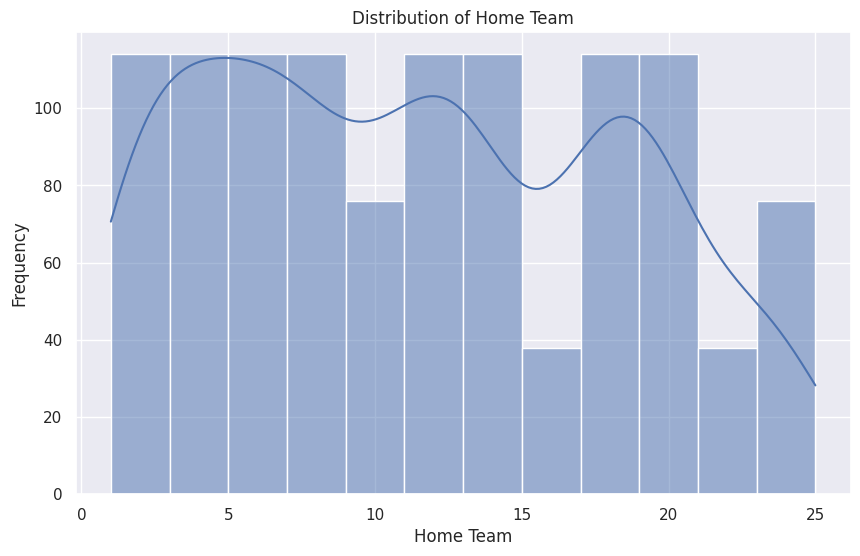

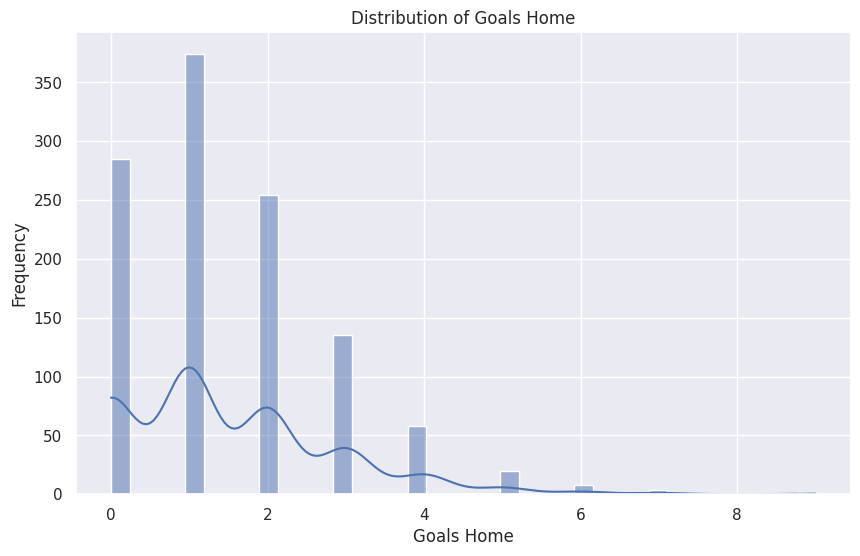

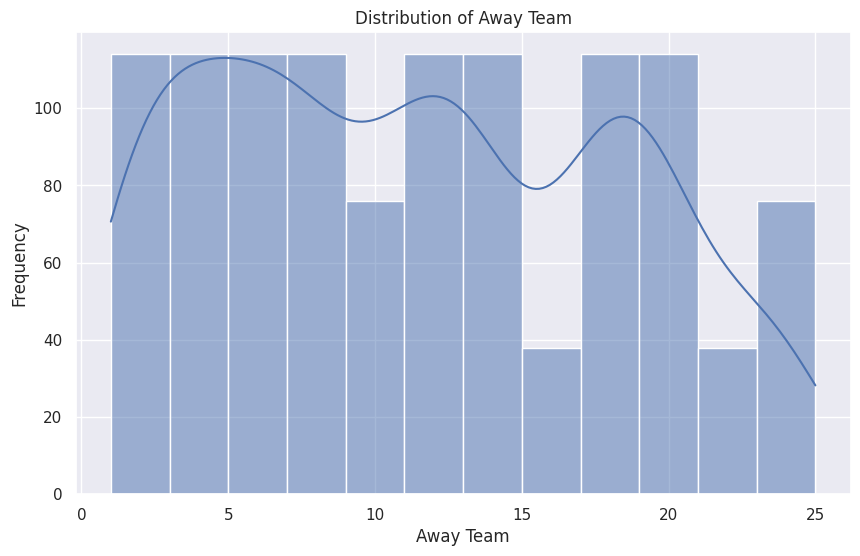

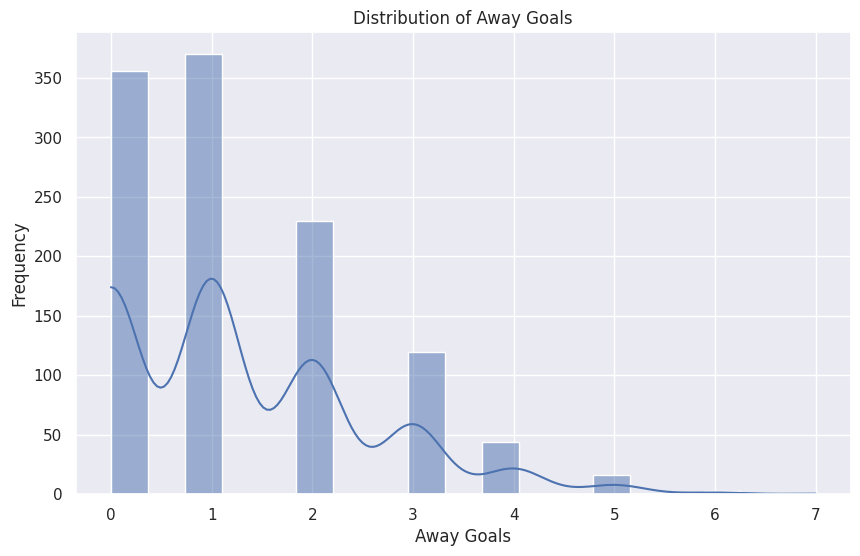

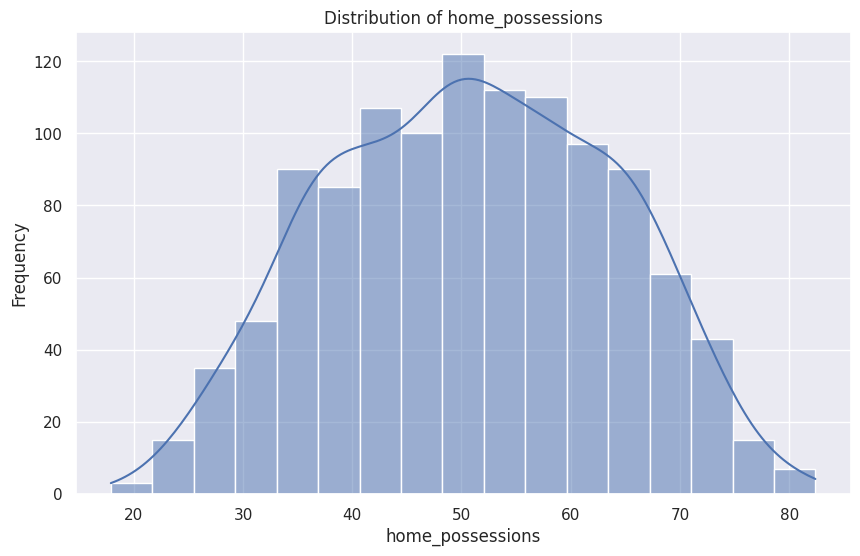

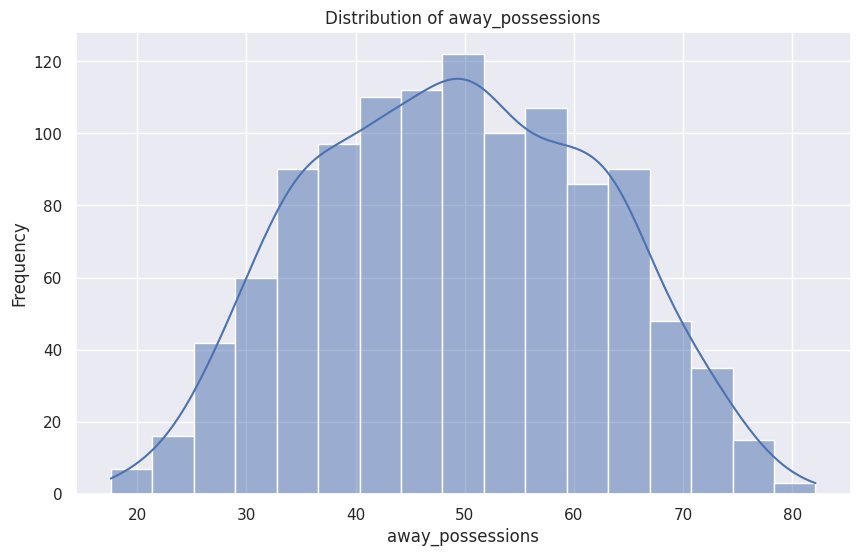

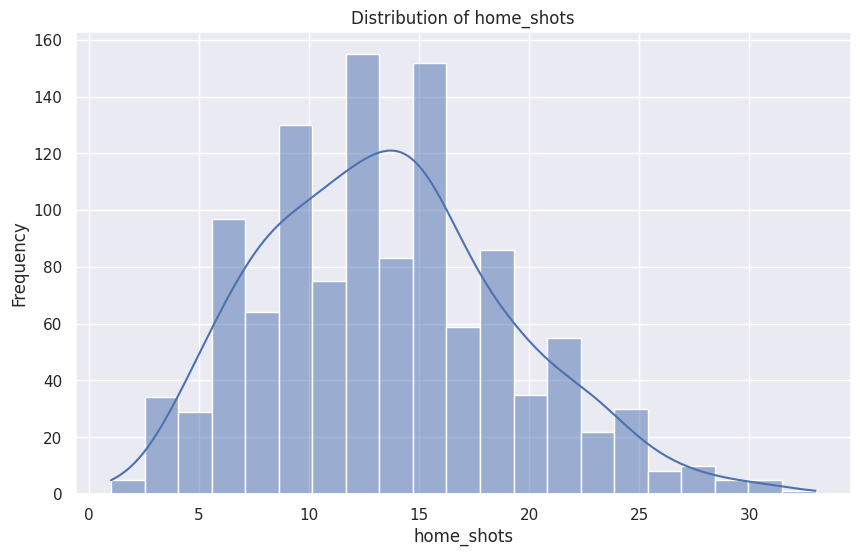

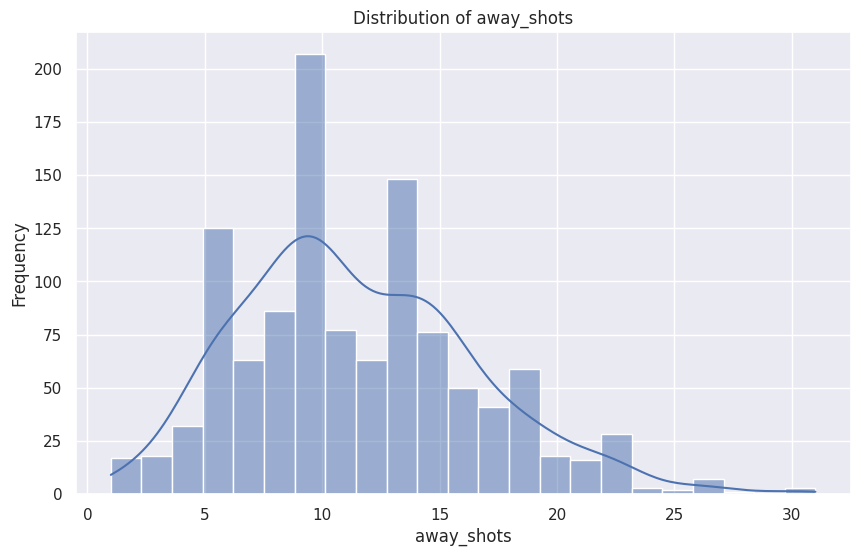

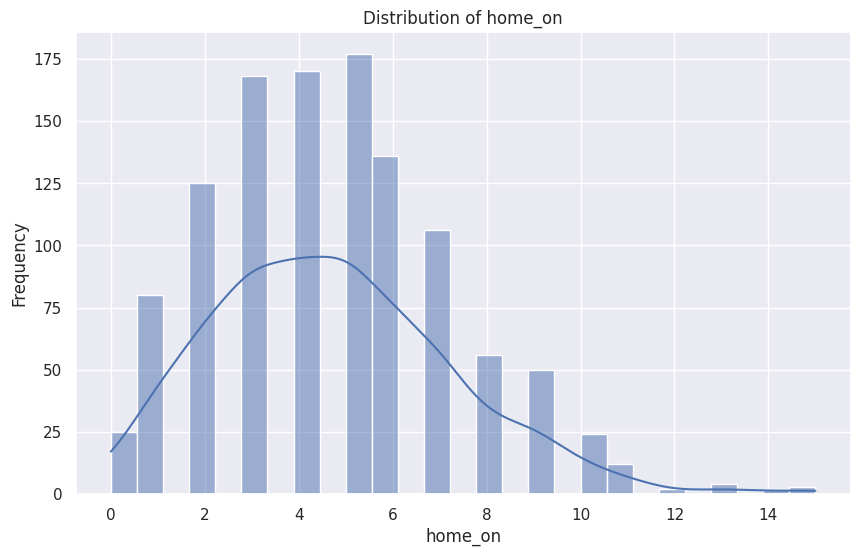

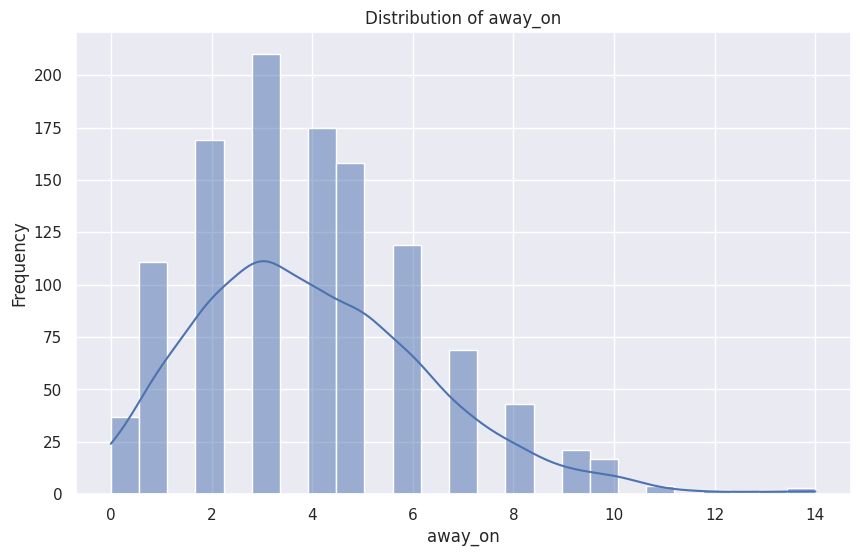

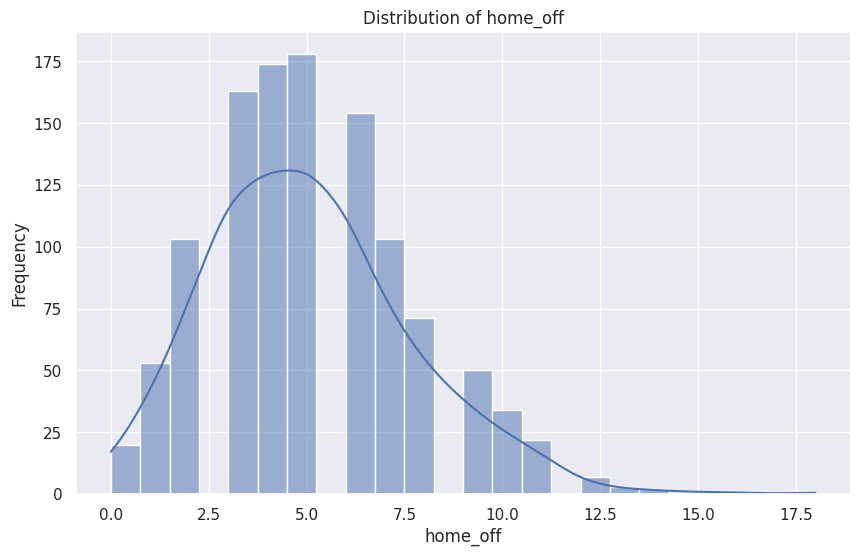

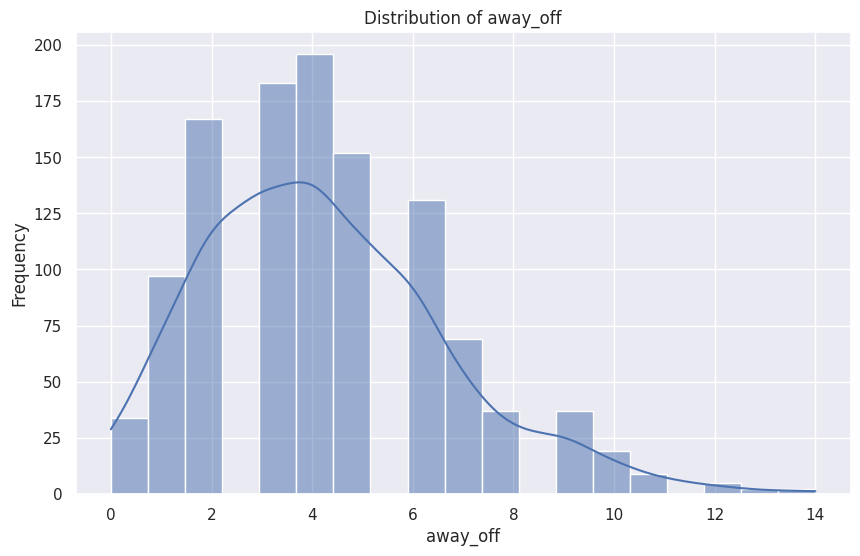

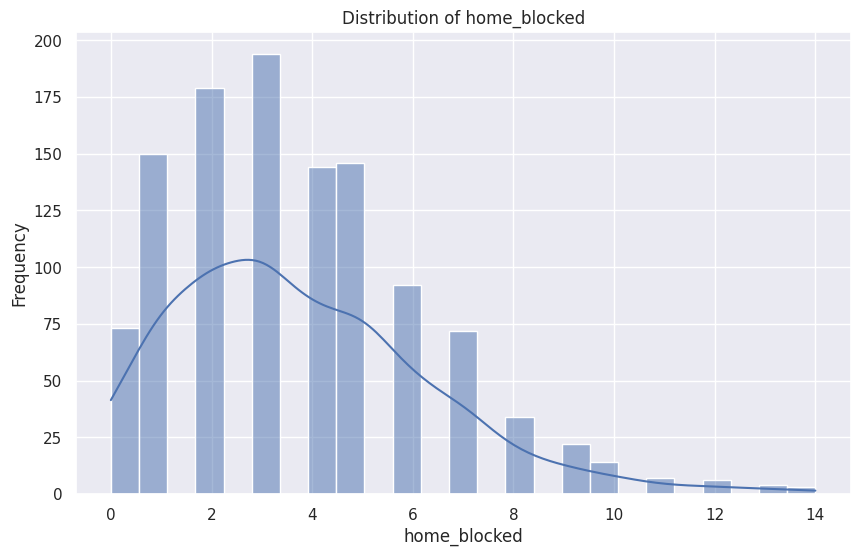

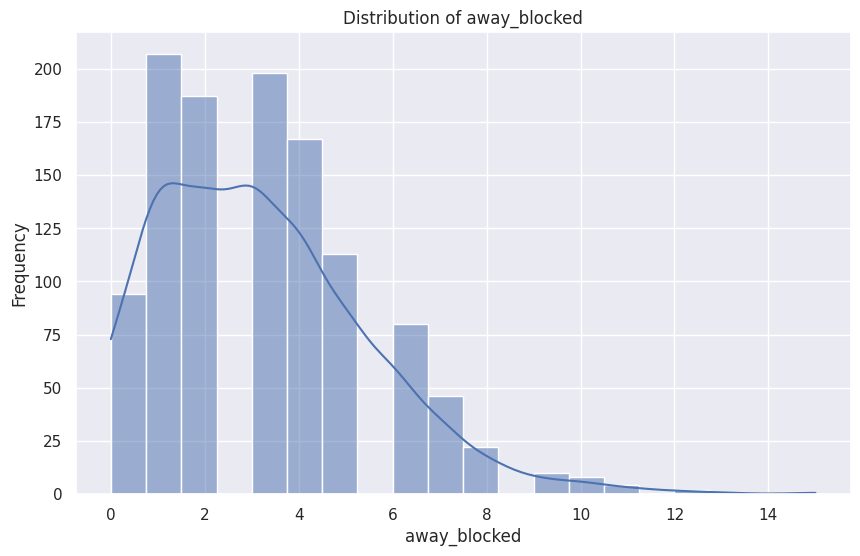

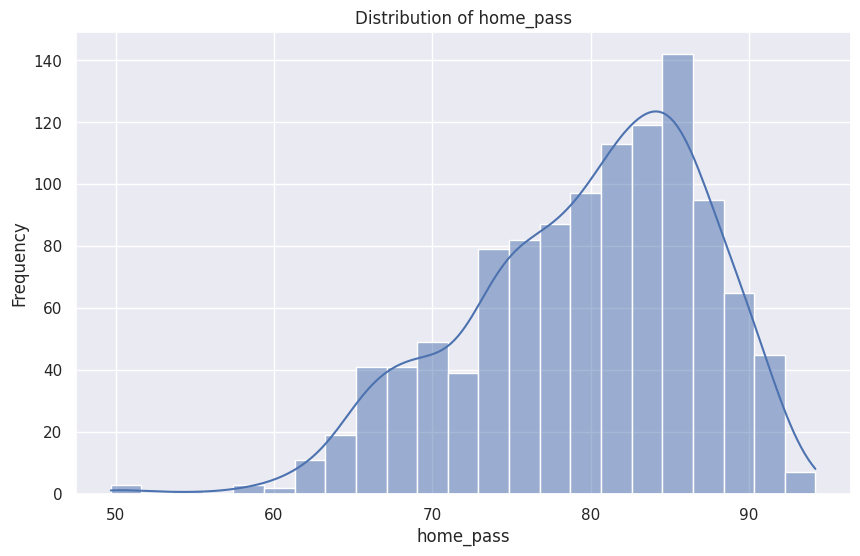

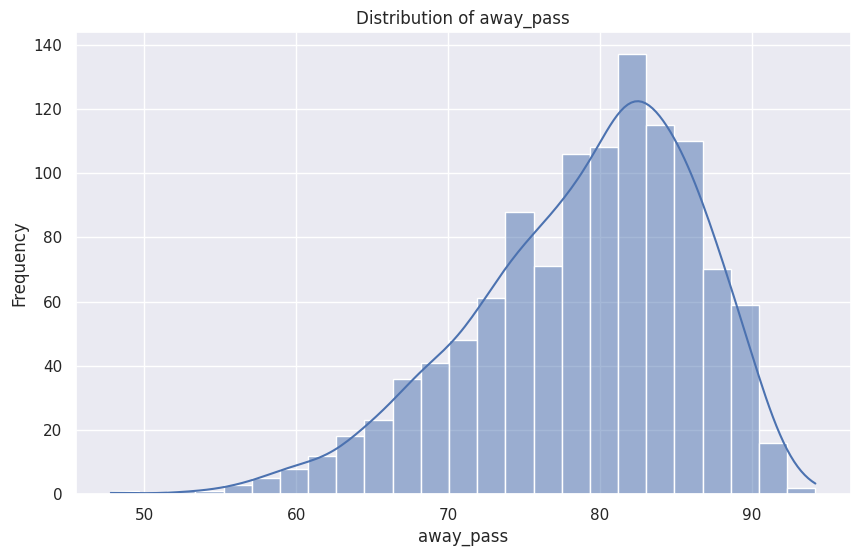

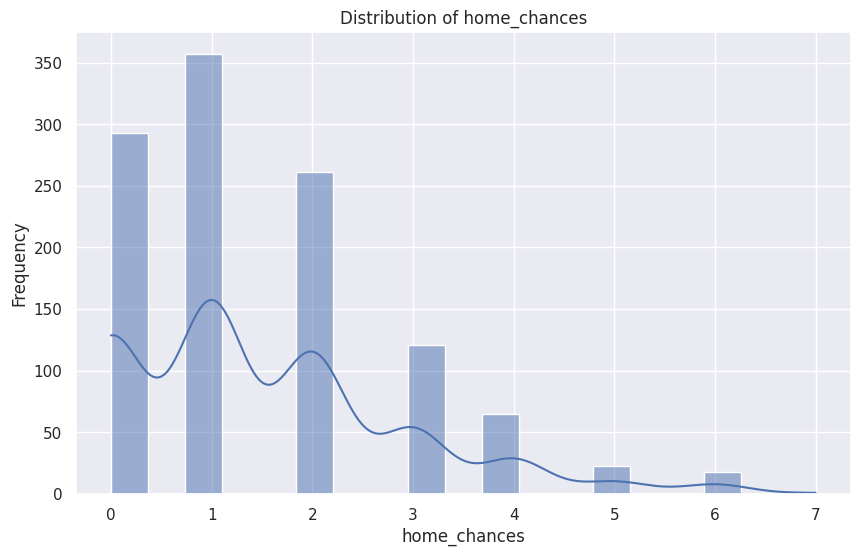

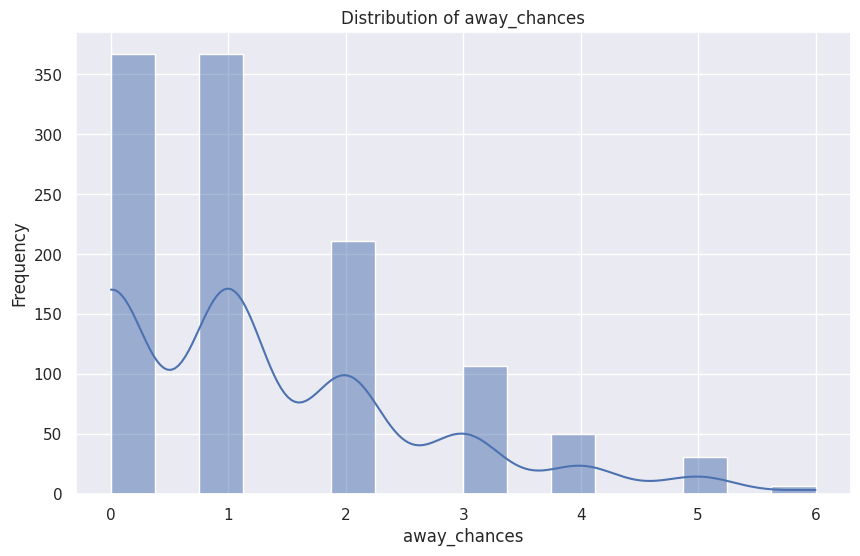

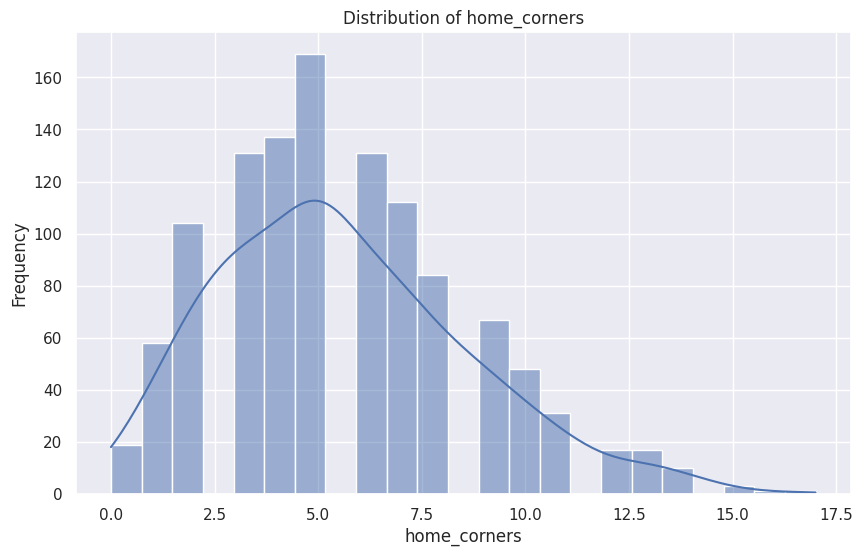

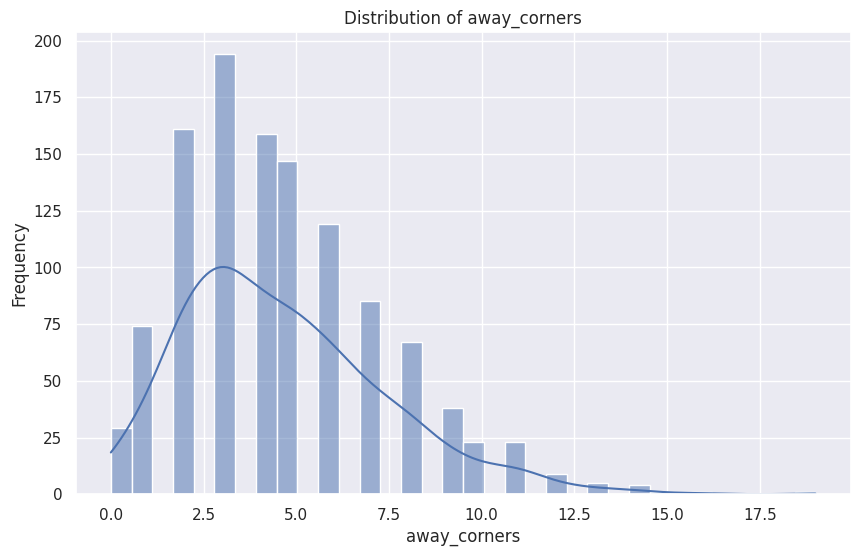

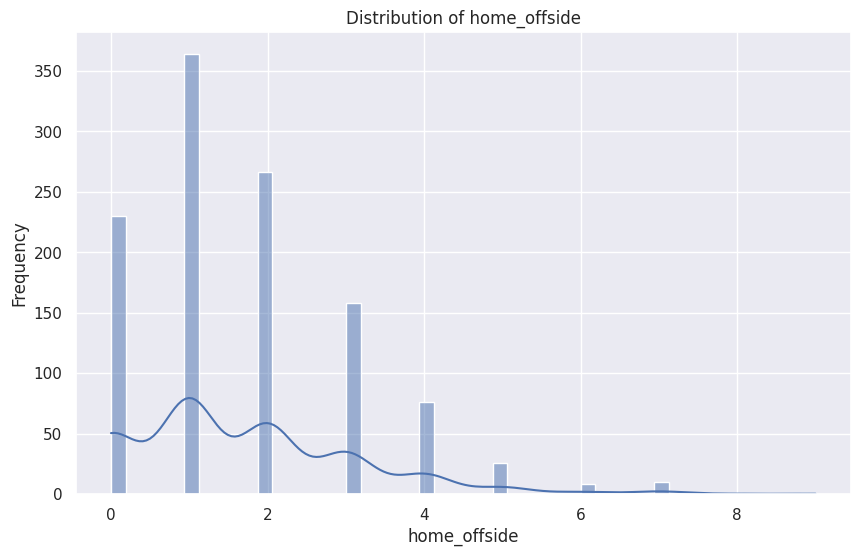

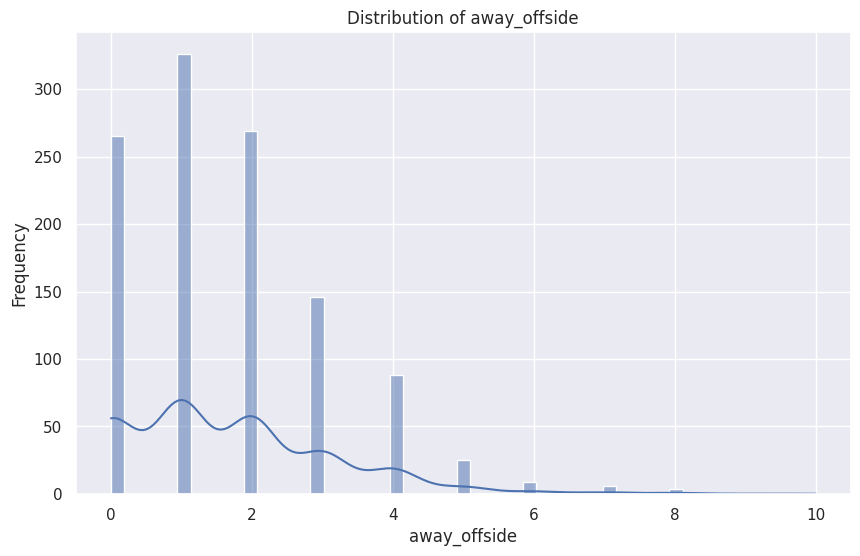

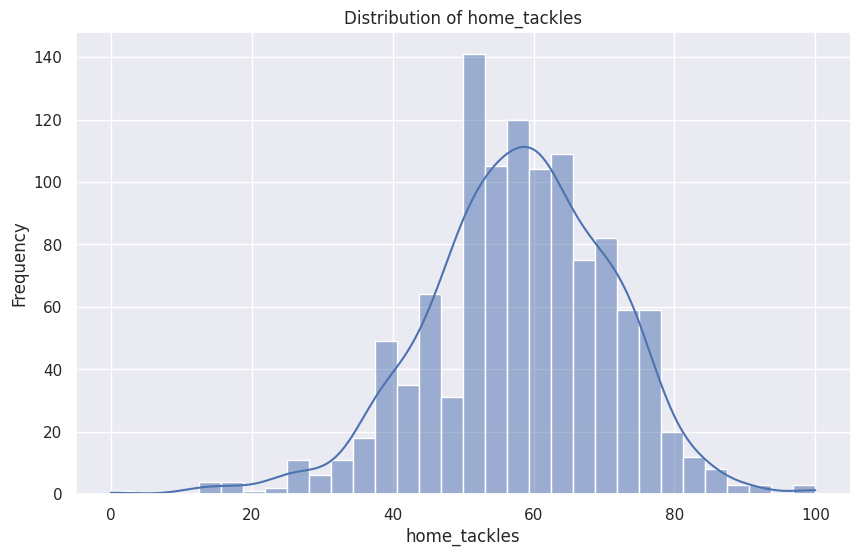

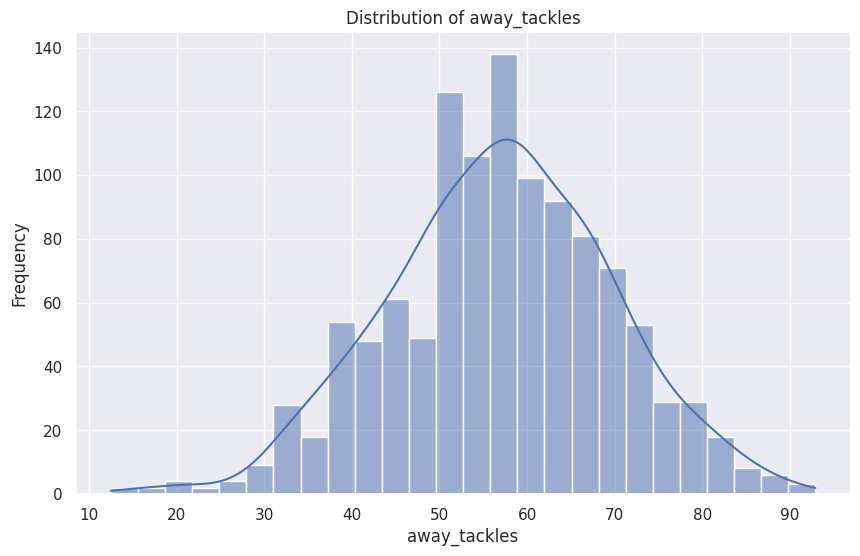

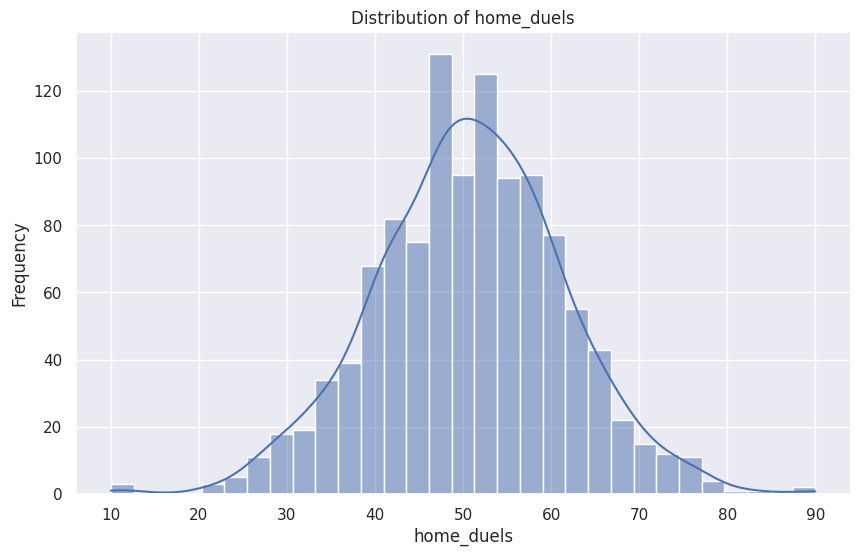

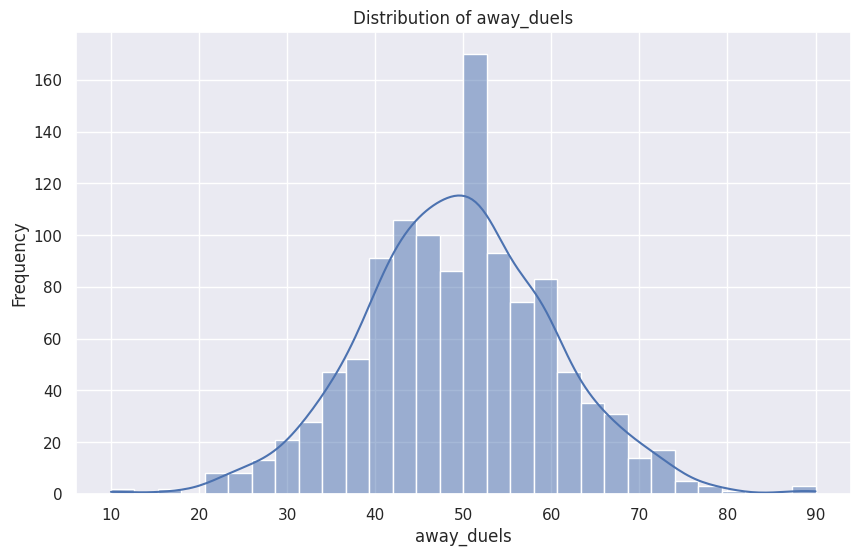

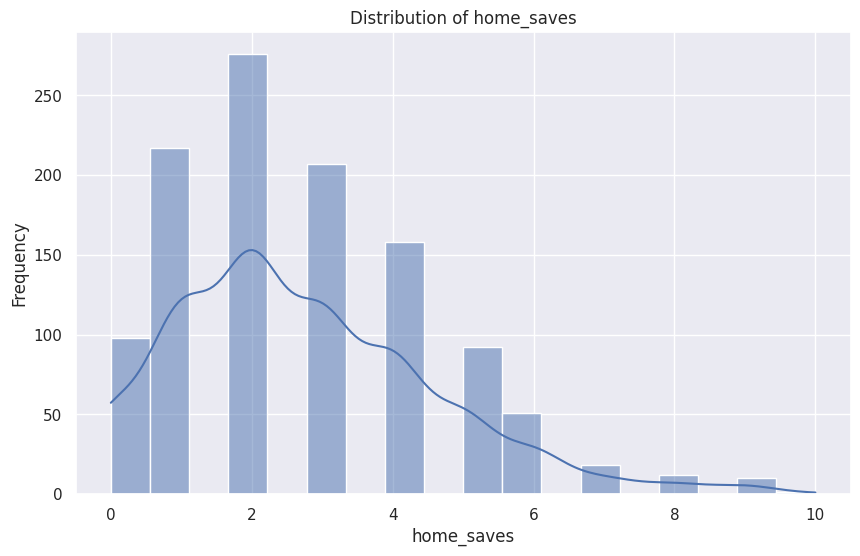

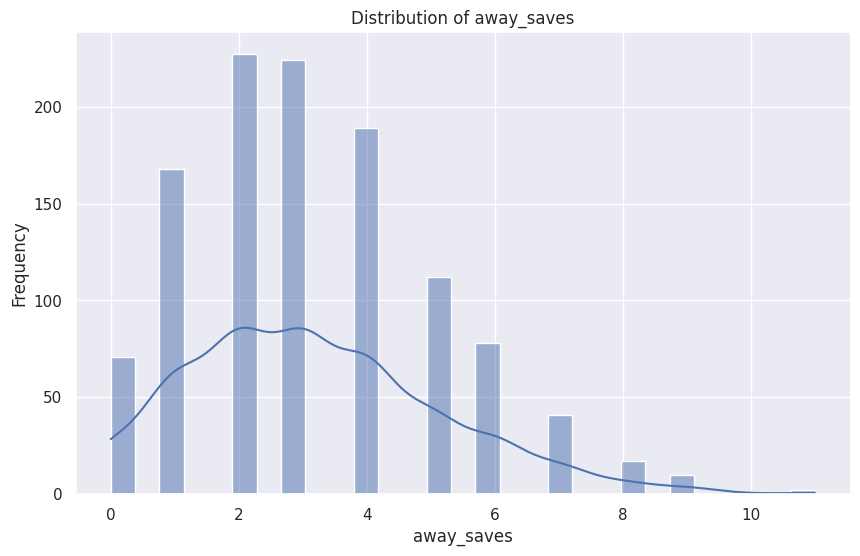

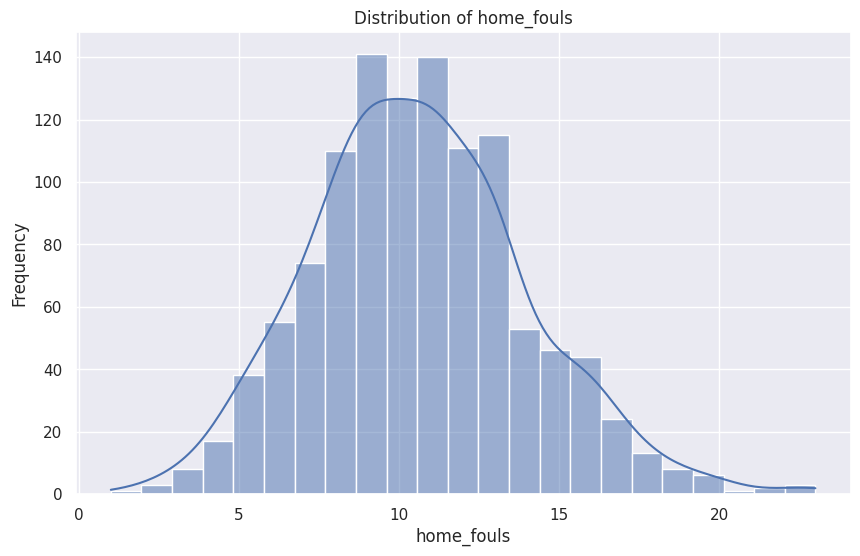

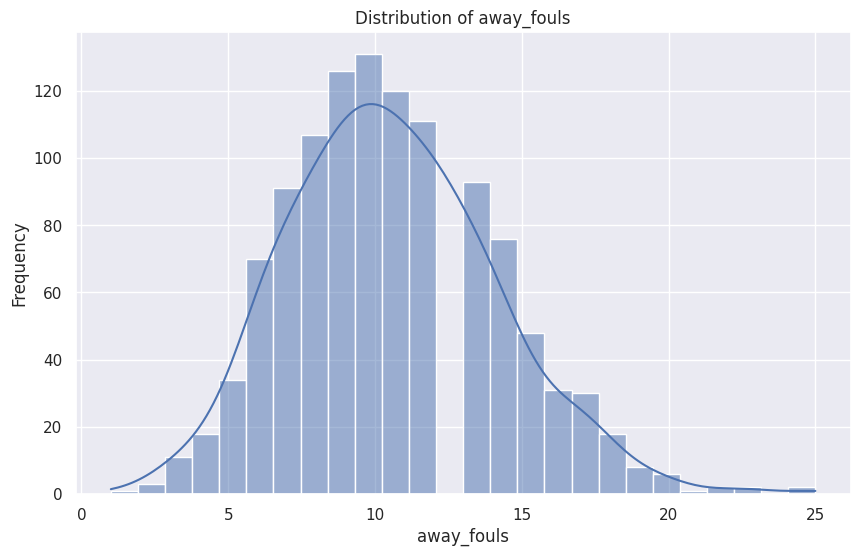

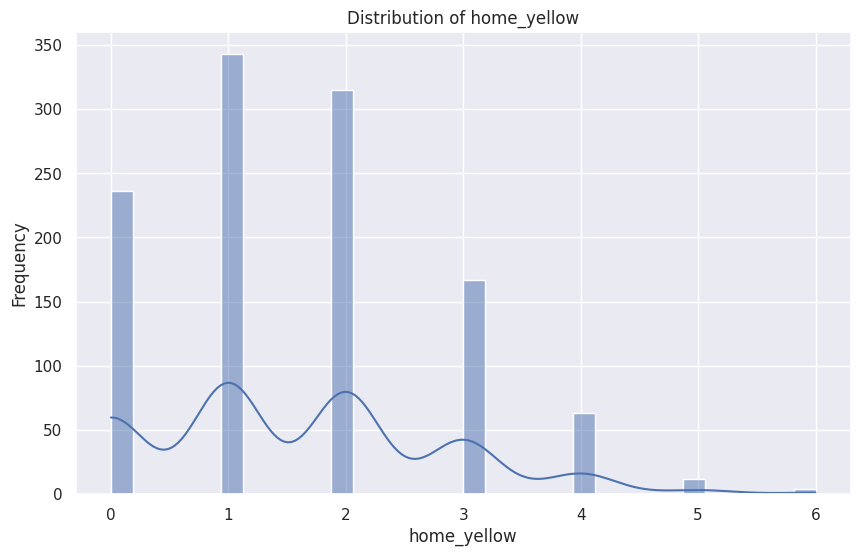

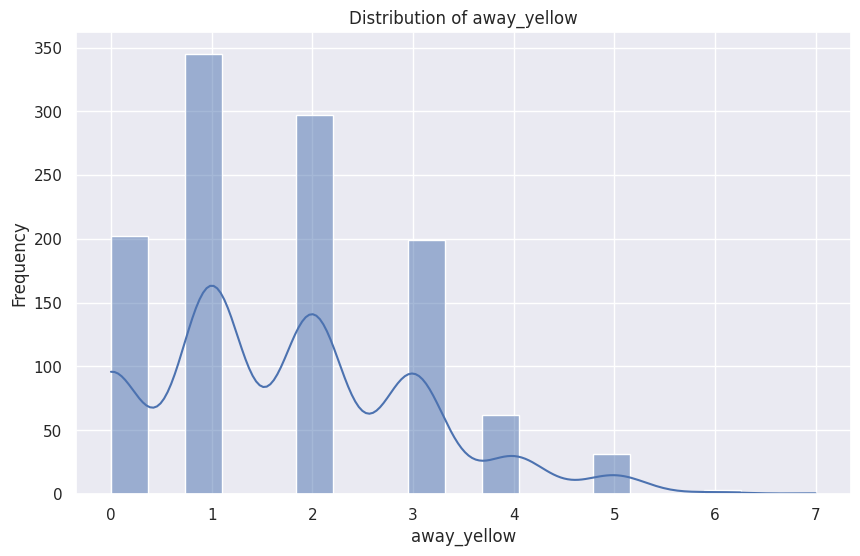

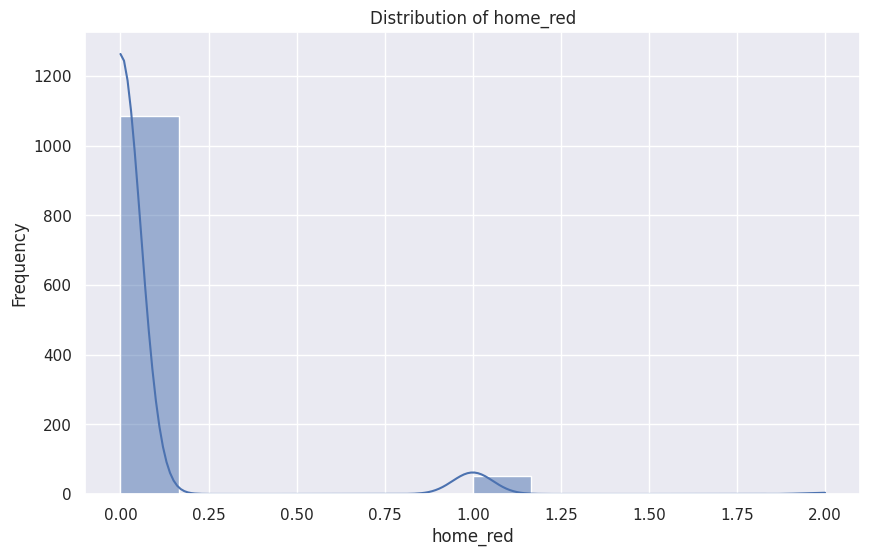

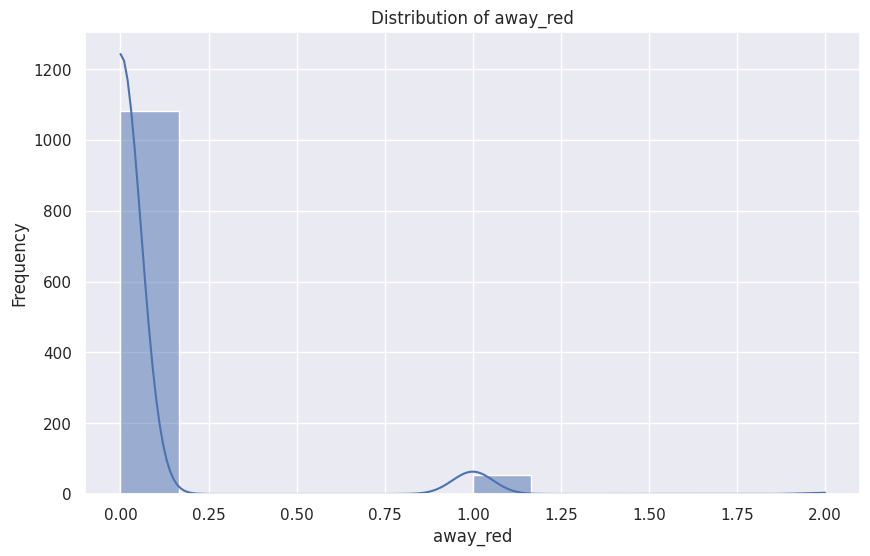

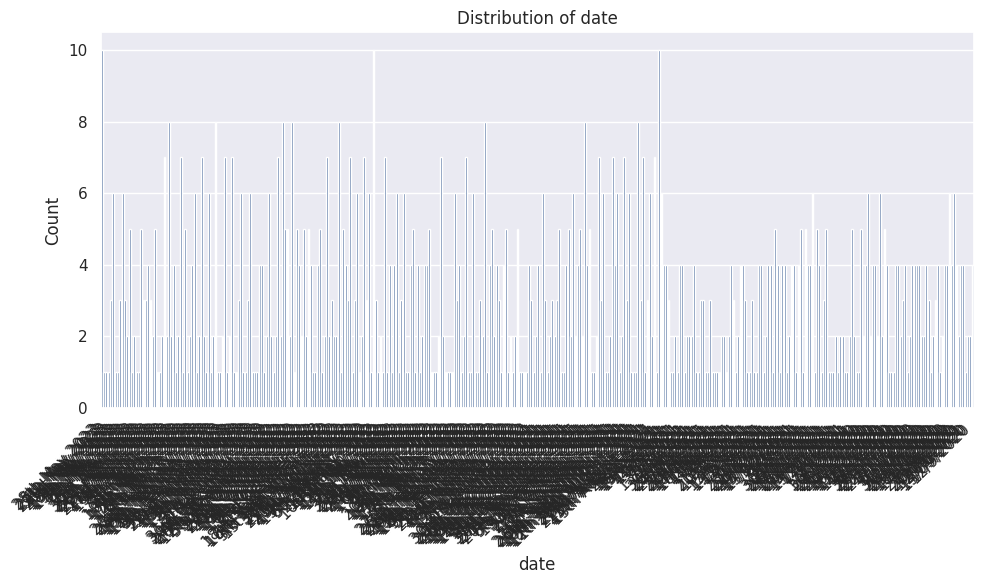

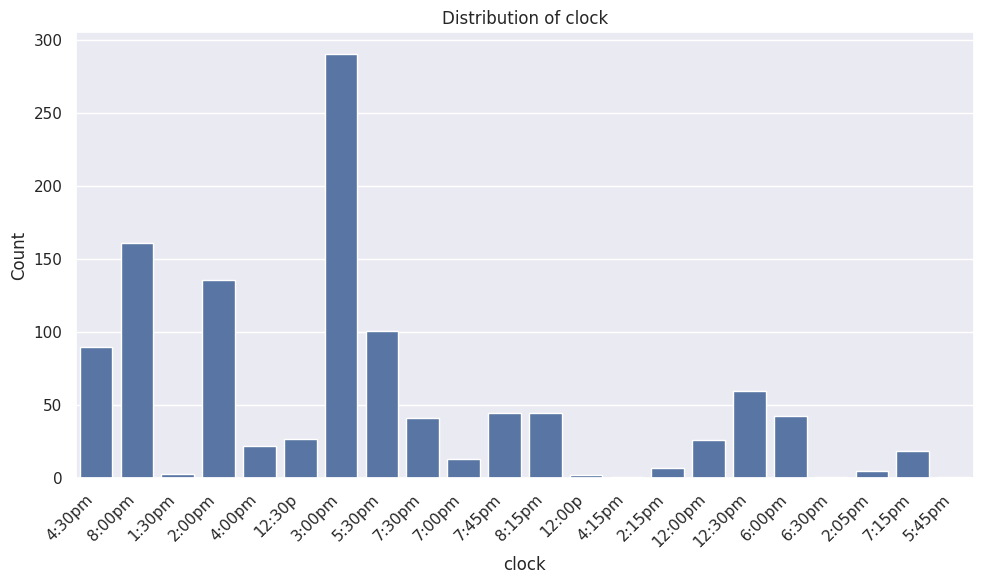

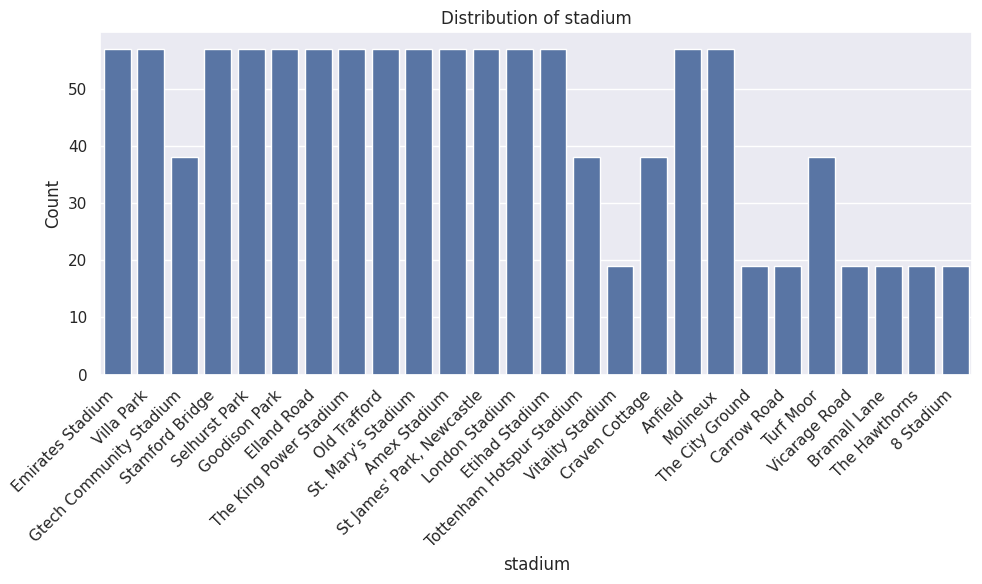

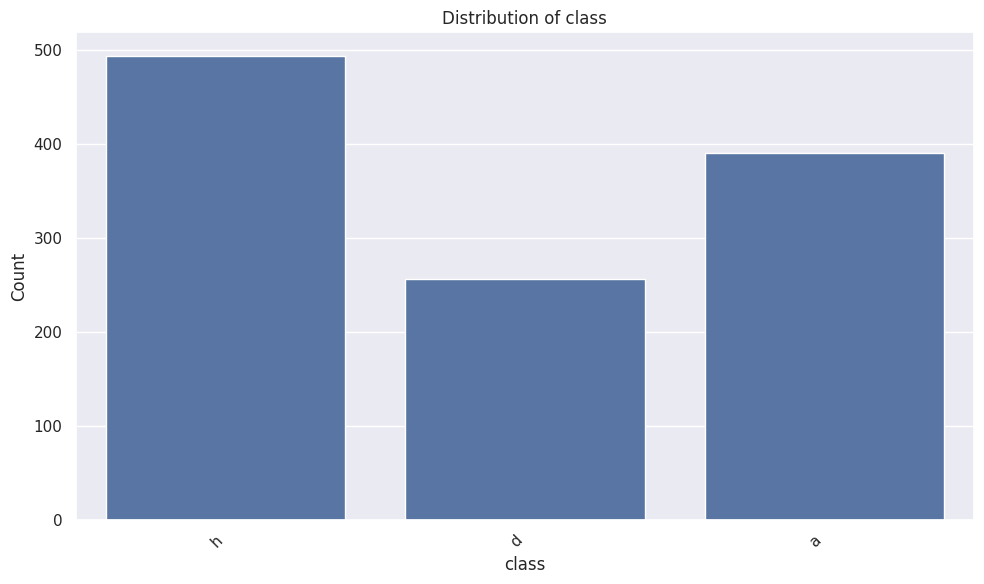

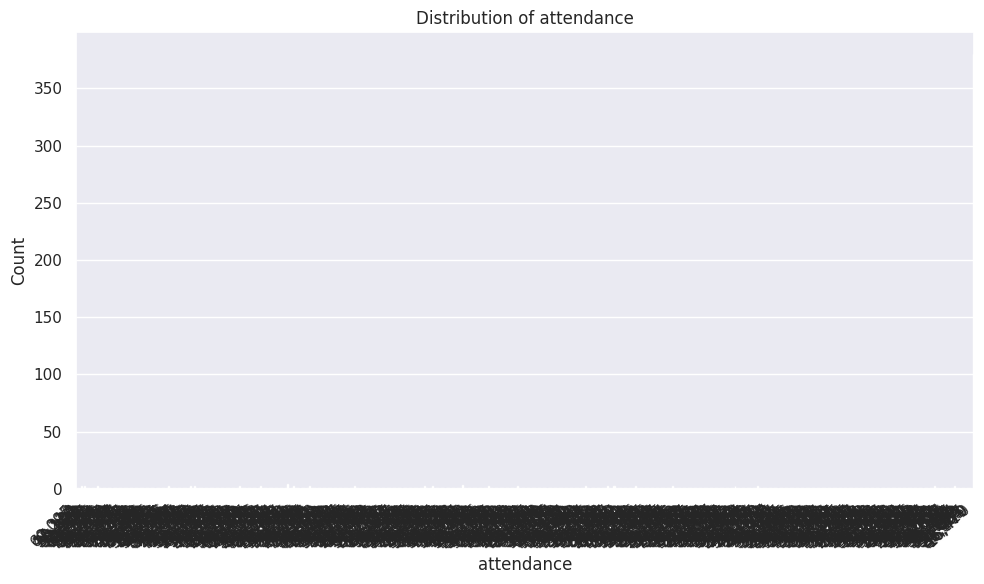

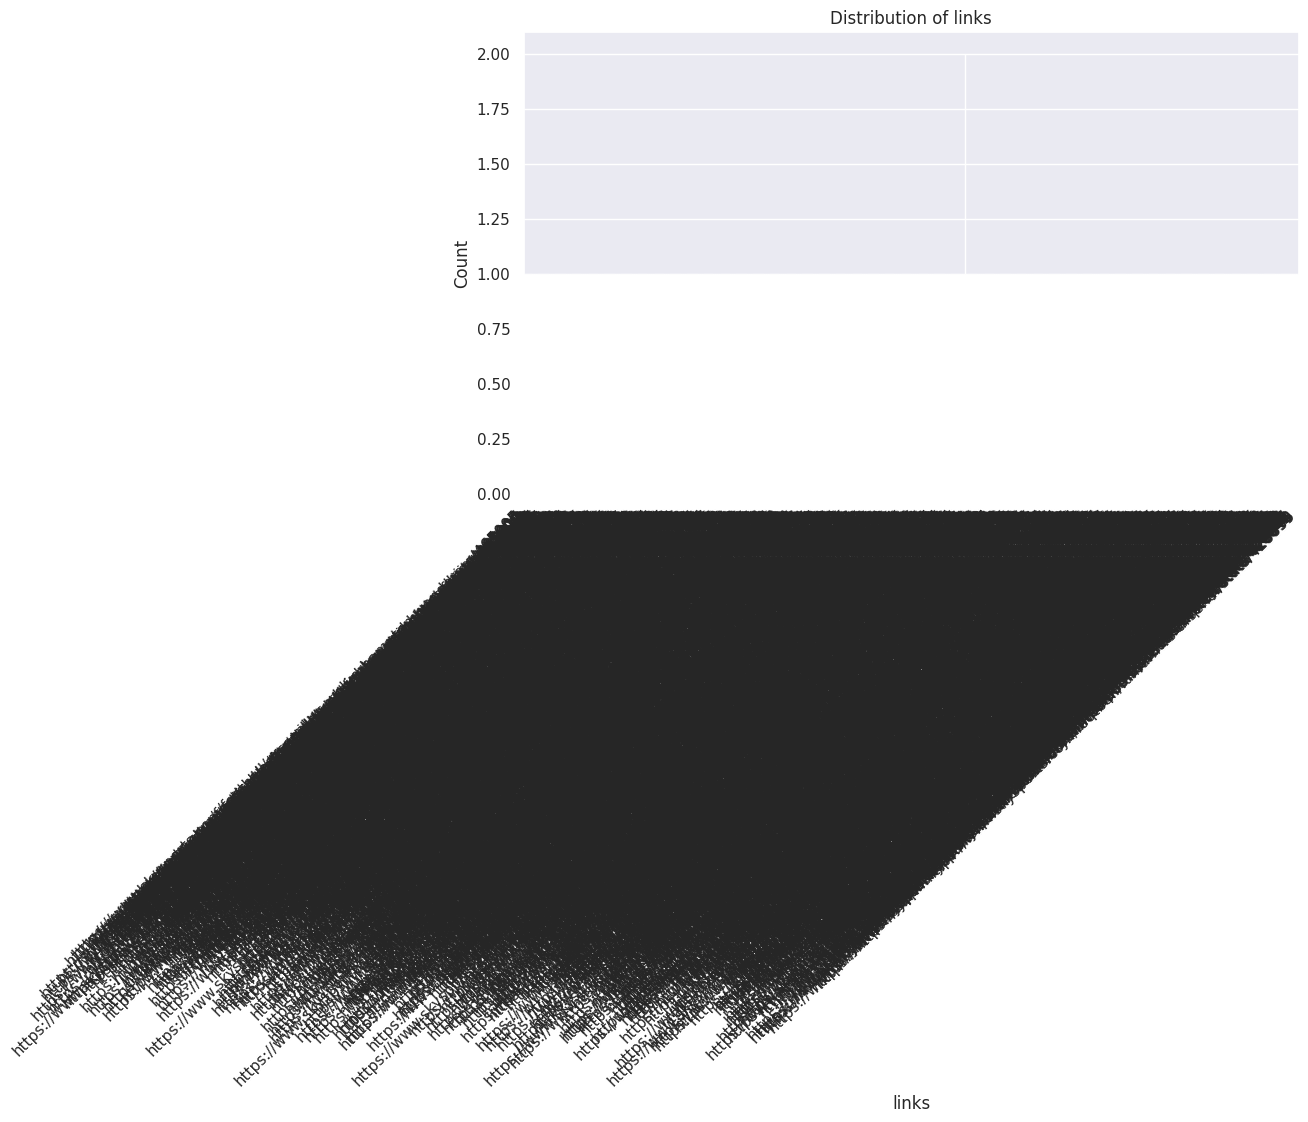

Value counts for date:
date
28th May 2023         10
 22nd May 2022        10
23/05/2021            10
29th October 2022      8
12th November 2022     8
                      ..
15th May 2023          1
20/1/2021              1
22nd May 2023          1
24th May 2023          1
25th May 2023          1
Name: count, Length: 376, dtype: int64

Value counts for clock:
clock
3:00pm     291
8:00pm     161
2:00pm     136
5:30pm     101
4:30pm      90
12:30pm     60
7:45pm      45
8:15pm      45
6:00pm      43
7:30pm      41
12:30p      27
12:00pm     26
4:00pm      22
7:15pm      19
7:00pm      13
2:15pm       7
2:05pm       5
1:30pm       3
12:00p       2
4:15pm       1
6:30pm       1
5:45pm       1
Name: count, dtype: int64

Value counts for stadium:
stadium
Emirates Stadium             57
Villa Park                   57
Stamford Bridge              57
Selhurst Park                57
Goodison Park                57
Elland Road                  57
Old Trafford                 57
The King Pow

In [13]:
# Get a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Get a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Multivariate Analysis

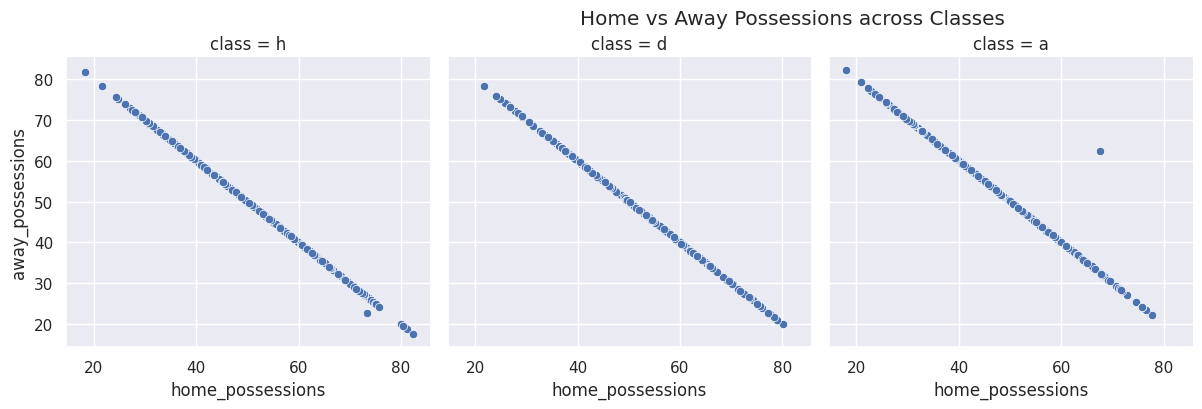

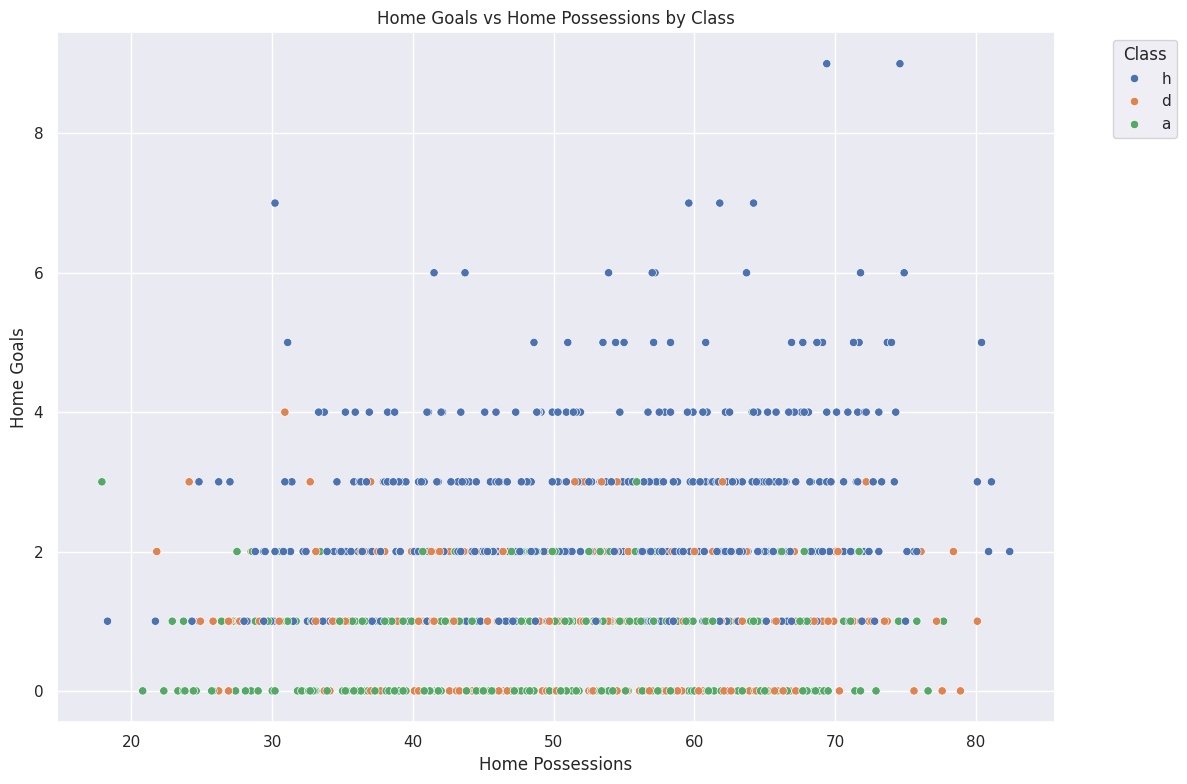

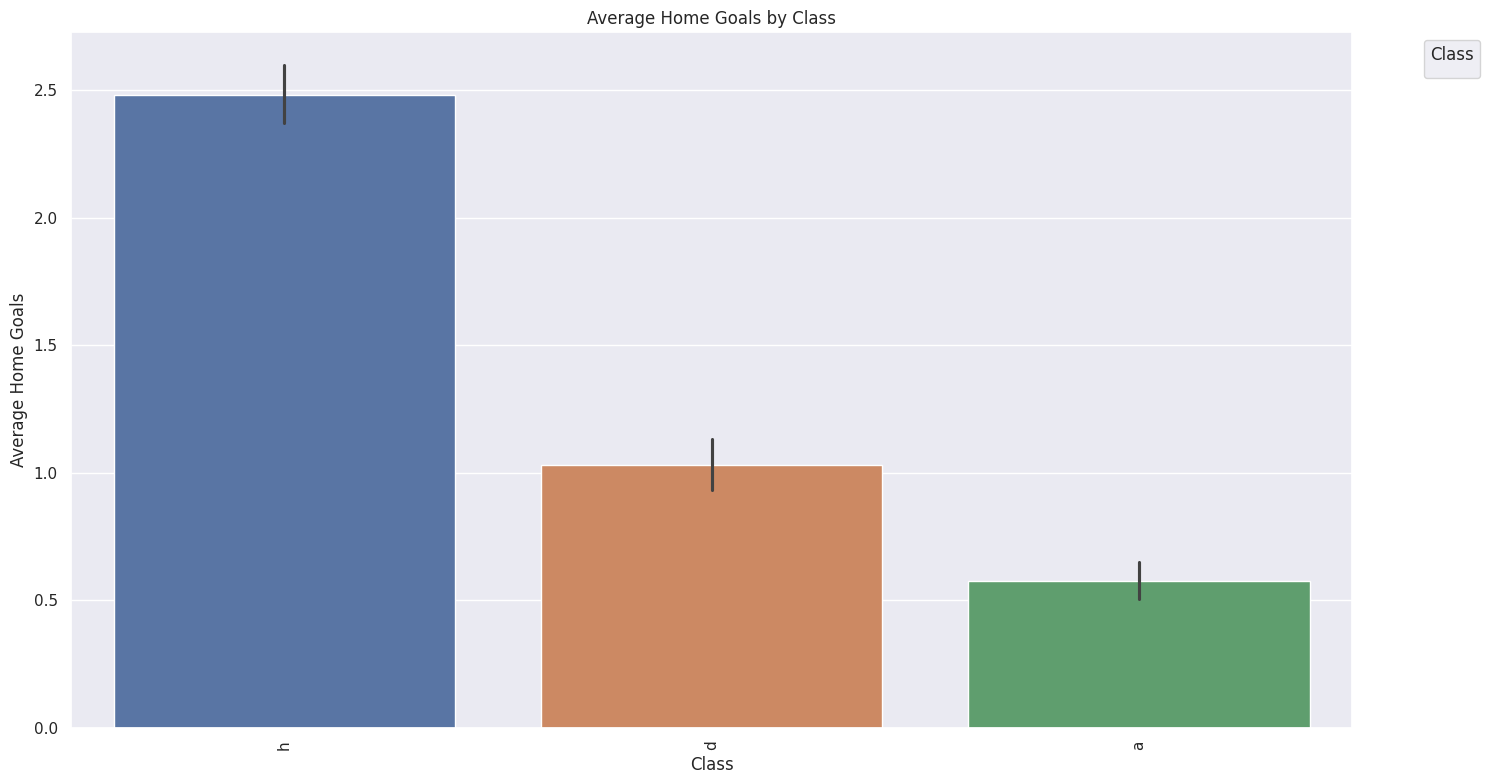

In [6]:
# Relationship between Range, Battery Capacity, and Year
g = sns.FacetGrid(df, col="class", col_wrap=4, height=4)
g.map(sns.scatterplot, "home_possessions", "away_possessions")
plt.suptitle('Home vs Away Possessions across Classes', y=1.02)
plt.show()

# Relationship between Price, Range, and Battery Type
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x="home_possessions", y="Goals Home", hue="class")
plt.title('Home Goals vs Home Possessions by Class')
plt.xlabel('Home Possessions')
plt.ylabel('Home Goals')
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Exploring relationships between a numerical variable and two categorical variables
# Price by Manufacturer and Battery Type (using a bar plot)
plt.figure(figsize=(15, 8))
sns.barplot(data=df, x="class", y="Goals Home", hue="class")
plt.title('Average Home Goals by Class')
plt.xlabel('Class')
plt.ylabel('Average Home Goals')
plt.xticks(rotation=90)
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

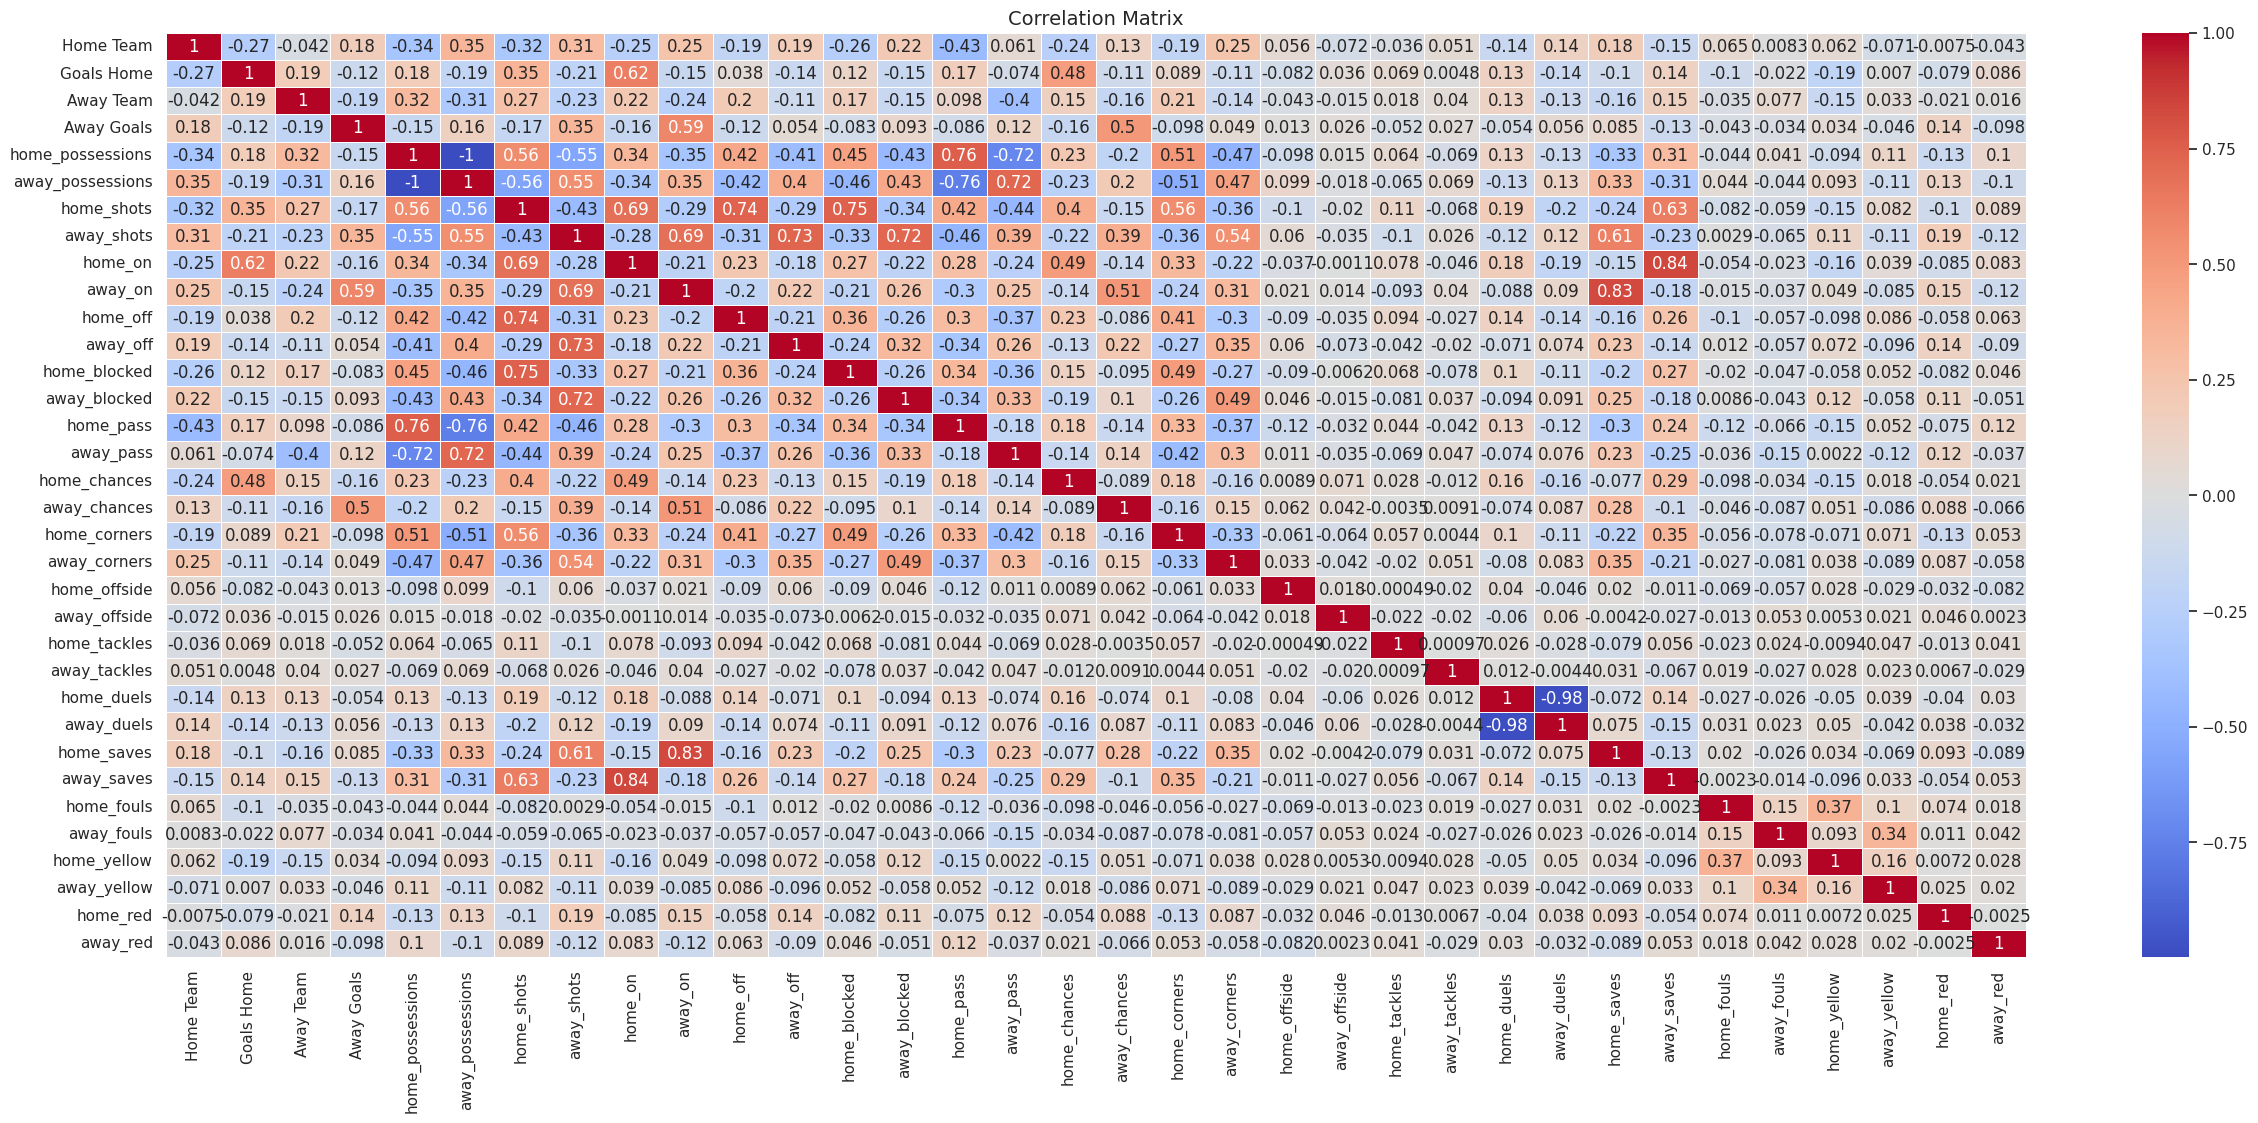

In [10]:
plt.figure(figsize=(30, 12))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you